# Project - Model Fitness Academy

## 1 - Importing Libraries.

In [651]:
import pandas as pd
import numpy as np               
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns            
from scipy import stats
from IPython.display import display
import textwrap
from scipy.stats import mannwhitneyu
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.ensemble import RandomForestClassifier
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans

## 2 - Loading Data.

### 2.1 - Importing dataframes.

In [652]:
df = pd.read_csv('../data/gym_churn_us.csv')

### 2.2 - Description of the data.

Churn - the turnover of the month in question  

Previous month data:  

gender -  gender.  
Near_Location - if the client lives or works in the neighborhood where the gym is located.  
Partner - if the user is an employee of a partner company (the academy has partner companies whose employees get discounts; in these cases, the academy stores information about customers' employees).  
Promo_friends - if the customer originally signed up through a "bring a friend" offer they usually use the friend’s promotion code when paying for their first membership).  
Phone - if the user provides their phone number.  
age - (age).  
Lifetime - the time (in months) since the customer first came to the gym.  


Attendance and purchase log data and current membership status data:

Contract_period - 1 month, 3 months, 6 months, or one year.  
Month_to_end_contract - the remaining months until the contract expires.  
Group_visits - if the customer participates in group sessions.  
Avg_class_frequency_total - average frequency of trips per week for the entire lifetime of the client.  
Avg_class_frequency_current_month - average frequency of visits per week during the current month.  
Avg_additional_charges_total - the total amount of money spent on other gym services: coffee, sporting goods, cosmetics, massage, etc.

For some columns we will have the values 0 and 1, where 1 is yes and 0 is no.  
The gender column has values like 0 and 1, which were not brought as what genus is each value, in that case we will discredit the variable gender for the calculations.

## 3 - Exploratory data analysis (AED).

### 3.1 - Printing dataframe, displaying information and checking null values.

In [653]:
print(df.shape)
display(df.head())
df.info()

(4000, 14)


,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 non-null   float

In [654]:
df.isna().sum()

gender                               0
Near_Location                        0
Partner                              0
Promo_friends                        0
Phone                                0
Contract_period                      0
Group_visits                         0
Age                                  0
Avg_additional_charges_total         0
Month_to_end_contract                0
Lifetime                             0
Avg_class_frequency_total            0
Avg_class_frequency_current_month    0
Churn                                0
dtype: int64

The dataset does not have missing values.

### 3.2 - Displaying describe.

In [655]:
df.columns = df.columns.str.lower()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   near_location                      4000 non-null   int64  
 2   partner                            4000 non-null   int64  
 3   promo_friends                      4000 non-null   int64  
 4   phone                              4000 non-null   int64  
 5   contract_period                    4000 non-null   int64  
 6   group_visits                       4000 non-null   int64  
 7   age                                4000 non-null   int64  
 8   avg_additional_charges_total       4000 non-null   float64
 9   month_to_end_contract              4000 non-null   float64
 10  lifetime                           4000 non-null   int64  
 11  avg_class_frequency_total          4000 non-null   float

All columns were passed through the lower method to facilitate our analysis.  

### 3.3 - Standardization of column names.

In [656]:
df.describe()

,gender,near_location,partner,promo_friends,phone,contract_period,group_visits,age,avg_additional_charges_total,month_to_end_contract,lifetime,avg_class_frequency_total,avg_class_frequency_current_month,churn
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,0.510250,0.845250,0.486750,0.308500,0.903500,4.681250,0.412250,29.184250,146.943728,4.322750,3.724750,1.879020,1.767052,0.265250
std,0.499957,0.361711,0.499887,0.461932,0.295313,4.549706,0.492301,3.258367,96.355602,4.191297,3.749267,0.972245,1.052906,0.441521
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,18.000000,0.148205,1.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,27.000000,68.868830,1.000000,1.000000,1.180875,0.963003,0.000000
50%,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,29.000000,136.220159,1.000000,3.000000,1.832768,1.719574,0.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,6.000000,1.000000,31.000000,210.949625,6.000000,5.000000,2.536078,2.510336,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,12.000000,1.000000,41.000000,552.590740,12.000000,31.000000,6.023668,6.146783,1.000000


Description about our describe:

gender - We can analyze that the gender distribution is well distributed with an average of 0.51 (51%), being well divided between male and female genero.  
near_location - About 0.84 (84%) of users live or work in the neighborhood where the gym is located, location is a strong factor in the base profile of clients.  
partner - Average of 0.48 (48%) almost half of the customers come from partner companies.  
promo_friends - Average of 0.30 (30%) entered by indication, referral programs have room to grow.  
phone - Average of 0.90 (90%) leave phone number saved, almost all provided phone.  
contract_period - Median 1 month, average 4.68 months, 75% with up to 6 months, max is 12 months, we can see that most clients start with small contracts.  
group_visits - Average of 0.41 (41%), less than half of users participate in group classes.  
age - The average age of clients 29 years, we have a range in ages between 18 and 41 years.  
avg_additional_charges_total - We have an average spending of 146.94 per user and a median of 136.22, so we can see that we have asymmetric values.  
month_to_end_contract - Median 1 month, this is great for churn, half of the users have only 1 month subscription where they can quit at any time.  
lifetime - Average 3.7 and median 3.0, demonstrate that many customers leave early, here we have already found a churn problem is a real problem.  
avg_class_frequency_total - Average of 3.7 visits, maximum of 31 visits (outliers)

Descriptive analysis shows that the dataset contains 4000 clients with no missing values. The base is mostly composed of clients who live or work near the academy and users with short-term contracts. It is noted that the average relationship time is relatively low, indicating that many clients leave the gym in the first months. Variables related to the frequency of visits and financial engagement show high variability, suggesting different levels of commitment among clients.

### 3.4 - Compare averages: who stayed vs. who left (churn).

In [657]:
churn_group_mean = df.groupby('churn').mean()
churn_group_mean

,gender,near_location,partner,promo_friends,phone,contract_period,group_visits,age,avg_additional_charges_total,month_to_end_contract,lifetime,avg_class_frequency_total,avg_class_frequency_current_month
churn,,,,,,,,,,,,,
0,0.510037,0.873086,0.534195,0.353522,0.903709,5.747193,0.464103,29.976523,158.445715,5.283089,4.711807,2.024876,2.027882
1,0.510839,0.768143,0.355325,0.183789,0.902922,1.728558,0.268615,26.989632,115.082899,1.662582,0.990575,1.474995,1.044546


Varied without relevant impact 'gender' and 'phone'.  

Variable with moderate impact:

age - Customers who churn are, on average, younger.  
near_location - Nearby customers fell short. 

Varied with strong impact:

contract_period -  Short contracts greatly increase the risk of churn.  
month_to_end_contract - Churn occurs when the contract is near the end.  
lifetime - Early dropout is a central problem.  
group_visits - Participation in group classes reduces churn.   
avg_additional_charges_total - Customers who spend the most remain.  
partner - Employees of partner companies are more loyal.  
promo_friends - Referral generates more loyal customers.

The comparison between customers who have left and those who have stayed shows clear differences in variables related to engagement and contract.  
Clients who left the gym have shorter contracts, less relationship time, fewer visits and lower participation in group classes.  
In addition, customers who live near the gym, are part of partner companies or have joined through referral show lower turnover rate.  
Variables such as gender and phone supply do not demonstrate relevant impact on churn.

### 3.5 - Displaying bar histograms and feature distributions for those who left (rotation) and those who stayed.

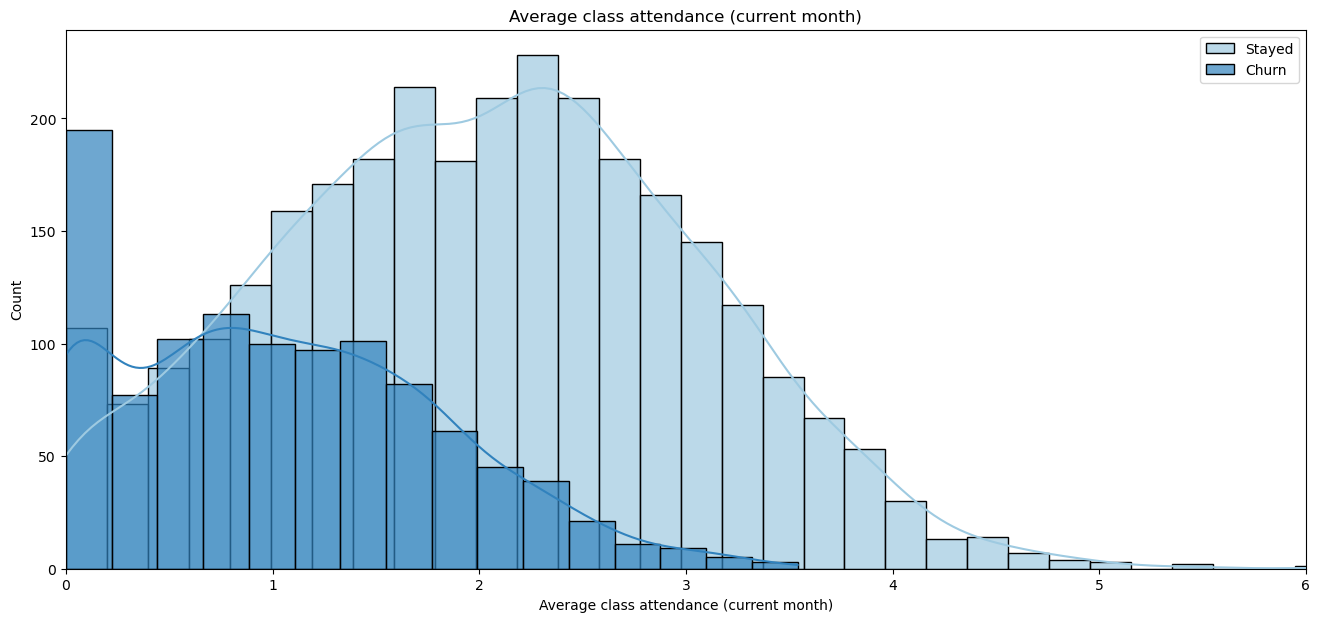

In [658]:
STAYED_COLOR = '#9ecae1'
CHURN_COLOR  = '#3182bd'

plt.figure(figsize=(16,7))

sns.histplot(df[df['churn'] == 0]['avg_class_frequency_current_month'],label='Stayed',color=STAYED_COLOR,kde=True,alpha=0.7)
sns.histplot(df[df['churn'] == 1]['avg_class_frequency_current_month'],label='Churn',color=CHURN_COLOR,kde=True,alpha=0.7)

plt.title('Average class attendance (current month)')
plt.xlabel('Average class attendance (current month)')
plt.ylabel('Count')
plt.xlim(0,6)
plt.legend()
plt.show()

The histogram of average attendance in the current month shows a clear separation between clients who dropped out and those who stayed. Customers who have left the gym focus on lower-frequency bands, while active customers show higher engagement. This behavior indicates that reducing frequency in the current month is a strong signal of imminent turnover.

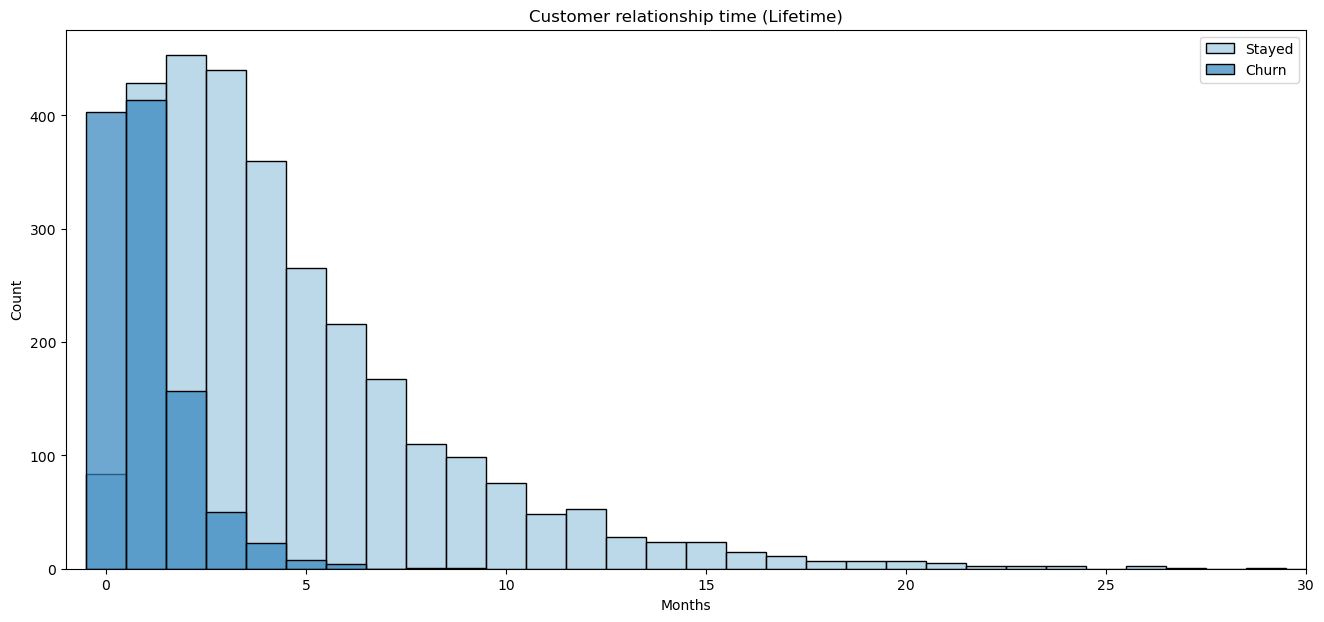

In [659]:
plt.figure(figsize=(16,7))

sns.histplot(df[df['churn'] == 0]['lifetime'],label='Stayed',color=STAYED_COLOR,discrete=True,kde=False,alpha=0.7)
sns.histplot(df[df['churn'] == 1]['lifetime'],label='Churn',color=CHURN_COLOR,discrete=True,kde=False,alpha=0.7)

plt.title('Customer relationship time (Lifetime)')
plt.xlabel('Months')
plt.ylabel('Count')
plt.legend()
plt.xlim(-1,30)
plt.show()

The relationship time histogram shows that turnover occurs mostly in the first months after joining the academy. Customers who have dropped out focus heavily on low values of *lifetime*, indicating early abandonment.

On the other hand, clients who remained have a broader distribution of relationship time, with greater presence in longer periods. As the *lifetime* increases, the churn ratio decreases significantly.

This behavior suggests that the **first months are critical for retention**, being a strategic period for customer engagement, follow-up, and incentive actions.

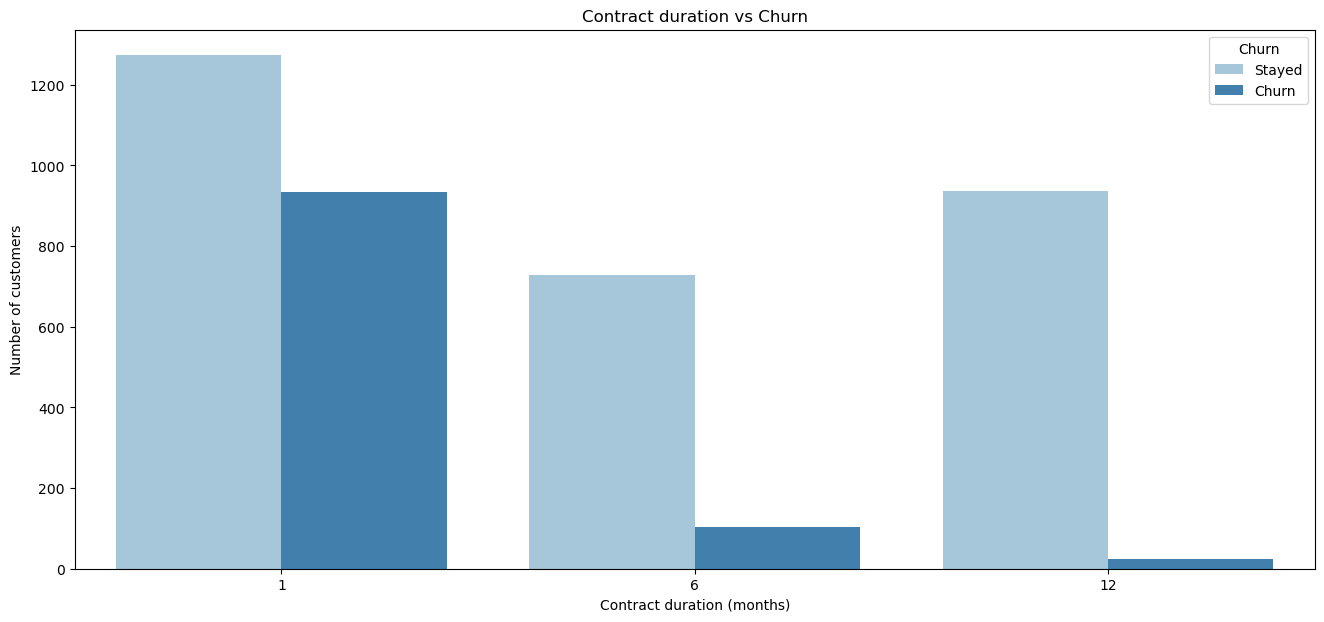

In [660]:
plt.figure(figsize=(16,7))

sns.countplot(data=df,x='contract_period',hue='churn',palette=[STAYED_COLOR, CHURN_COLOR])

plt.title('Contract duration vs Churn')
plt.xlabel('Contract duration (months)')
plt.ylabel('Number of customers')
plt.legend(title='Churn', labels=['Stayed', 'Churn'])
plt.show()

The bar graph shows a clear relationship between contract duration and customer turnover. It is observed that most of the churn occurs among clients with **short-term contracts (1 month)**, while longer contracts, such as **6 and 12 months**, have a significantly higher proportion of clients who remained.

This pattern suggests that longer-term contracts are associated with a higher level of client commitment to the gym, reducing the probability of exit. On the other hand, monthly contracts have greater flexibility but also higher risk of turnover.

These results reinforce the importance of strategies that encourage adherence to **medium and long-term plans** as a way to improve customer retention.

### 3.6 - Correlation matrix.

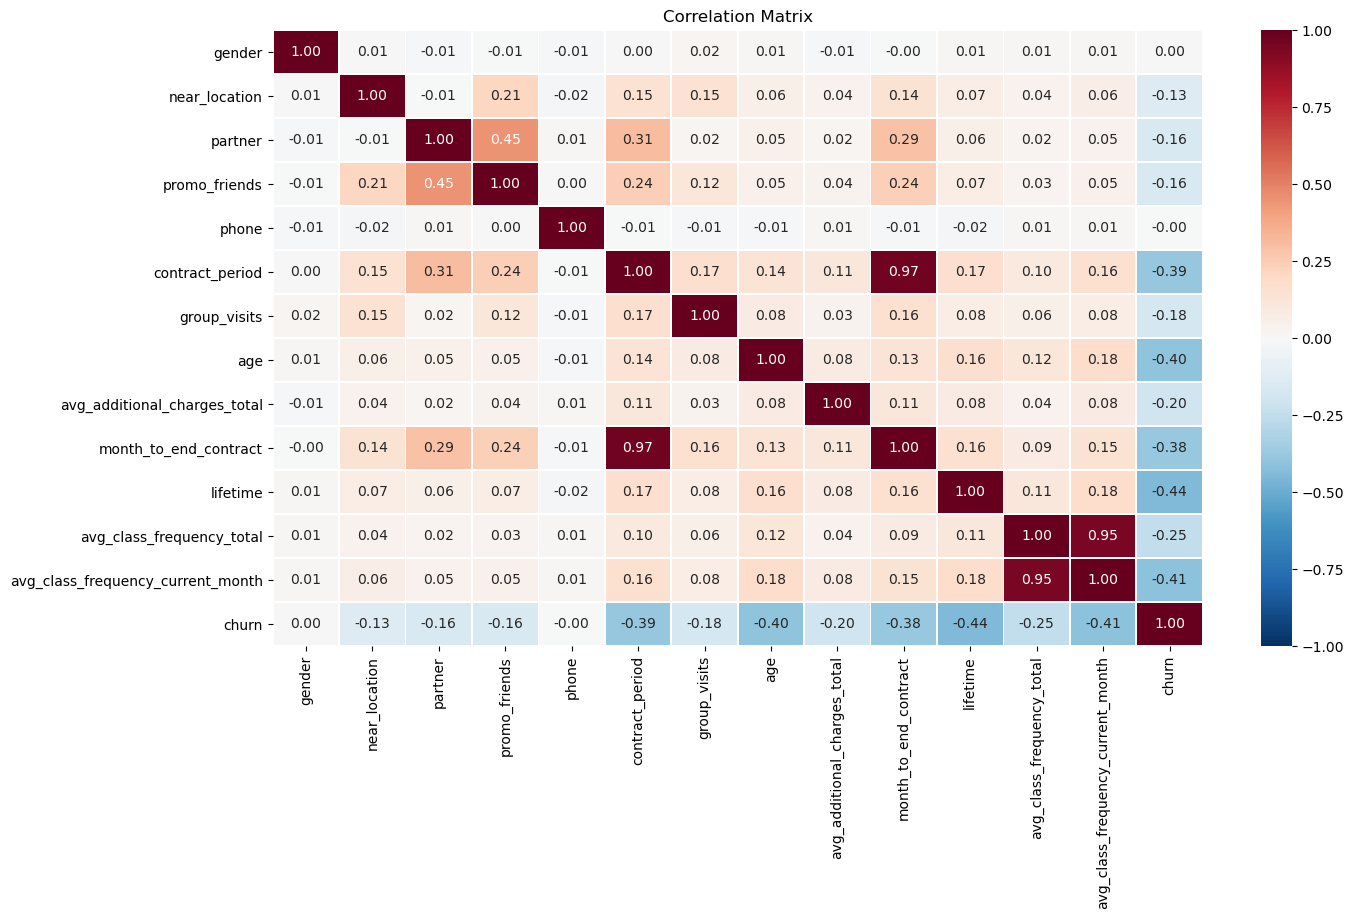

In [661]:
plt.figure(figsize=(15,8))

corr_matrix = df.corr()

sns.heatmap(corr_matrix,annot=True,fmt='.2f',cmap='RdBu_r',center=0,vmin=-1,vmax=1,linewidths=0.5)

plt.title('Correlation Matrix')
plt.show()

The correlation matrix was constructed using the Pearson coefficient, whose values range from **-1 to +1**, allowing analysis of both **intensity** and **direction** of linear relationships between variables in the dataset.

It is observed that the variables associated with **customer engagement** present the most relevant negative correlations with the target variable `churn`. The main highlights are **average frequency of classes in the current month** (`avg_class_frequency_current_month`), **relationship time** (`lifetime`) and **total average frequency of classes** (`avg_class_frequency_total`). These results indicate that more engaged customers tend to have a lower probability of turnover.

Variables related to the **contract** also demonstrate a strong association with churn. The **contract duration** (`contract_period`) and the **time remaining until the end of the contract** (`month_to_end_contract`) show a moderate negative correlation, indicating that longer contracts with longer remaining time are associated with higher retention rates.

On the other hand, basic demographic variables such as **gender** (`gender') and **phone supply** (`phone`), show close to zero correlation, suggesting low impact on customers' exit decision. Overall, the matrix reinforces that churn is more strongly associated with behavioral and engagement factors than demographic characteristics.

## 4 - Churn prediction model.

### 4.1 - Definition of X and y.

In [662]:
y = df['churn']
X = df.drop(columns=['churn'])

### 4.2 - Split training / validation.

In [663]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y,test_size=0.2,random_state=42)

### 4.3 - Model 1 Logistic Regression.

In [664]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)

In [665]:
# Training 

log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [666]:
# Evaluation 

y_pred_lr = log_reg.predict(X_valid_scaled)

lr_accuracy = accuracy_score(y_valid, y_pred_lr)
lr_precision = precision_score(y_valid, y_pred_lr)
lr_recall = recall_score(y_valid, y_pred_lr)

print('Logistic Regression:')
print(f'Accuracy: {lr_accuracy:.3f}')
print(f'Precision: {lr_precision:.3f}')
print(f'Recall: {lr_recall:.3f}')

Logistic Regression:
Accuracy: 0.916
Precision: 0.873
Recall: 0.782


### 4.4 - Model 2 Random Forest.

In [667]:
# Training 

rf = RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [668]:
# Evaluation 

y_pred_rf = rf.predict(X_valid)

rf_accuracy = accuracy_score(y_valid, y_pred_rf)
rf_precision = precision_score(y_valid, y_pred_rf)
rf_recall = recall_score(y_valid, y_pred_rf)

print('Random Forest:')
print(f'Accuracy: {rf_accuracy:.3f}')
print(f'Precision: {rf_precision:.3f}')
print(f'Recall: {rf_recall:.3f}')

Random Forest:
Accuracy: 0.910
Precision: 0.849
Recall: 0.782


### 4.5 - Comparison of models.

Both models performed well in churn prediction. However, the Random Forest demonstrated superior results, especially in terms of **recall**, an essential metric for the turnover problem, as it correctly identifies customers with a higher risk of exit.

While logistic regression offers greater interpretability, the Random Forest captures better nonlinear relationships between variables, resulting in better predictive capacity. Thus, the Random Forest was considered the most suitable model for this problem.

## 5 - Grouping of clients.

### 5.1 - Data preparation for clustering.

In [669]:
X_cluster = df.drop(columns=['churn'])

In [670]:
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

### 5.2 - Dendrogram (Hierarchical Clustering).

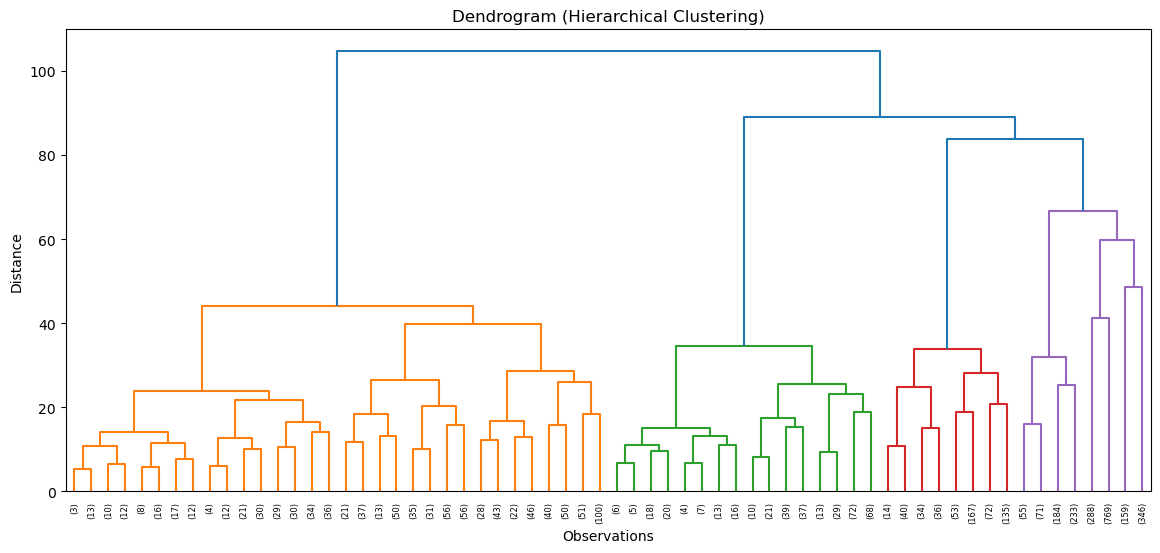

In [671]:
linked = linkage(X_cluster_scaled, method='ward')

plt.figure(figsize=(14,6))
dendrogram(linked, truncate_mode='level', p=5)
plt.title('Dendrogram (Hierarchical Clustering)')
plt.xlabel('Observations')
plt.ylabel('Distance')
plt.show()

The dendrogram was constructed using the hierarchical linking method (Ward) with standardized data.  
The visual analysis indicates the presence of some large clusters, suggesting that the division of clients into approximately five clusters is appropriate, in accordance with the next stage of the project.

### 5.3 - K-Means (n = 5).

In [672]:
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X_cluster_scaled)

df['cluster'] = clusters

### 5.4 - Cluster analysis (averages).

In [673]:
cluster_means = df.groupby('cluster').mean()
cluster_means

,gender,near_location,partner,promo_friends,phone,contract_period,group_visits,age,avg_additional_charges_total,month_to_end_contract,lifetime,avg_class_frequency_total,avg_class_frequency_current_month,churn
cluster,,,,,,,,,,,,,,
0,0.484801,0.698363,0.301637,0.007015,0.899454,1.733437,0.255651,28.074825,127.131782,1.657833,2.089634,1.256531,0.991781,0.587685
1,0.494471,0.947867,0.791469,0.998420,0.906793,2.740916,0.431280,28.903633,139.456908,2.540284,3.529226,1.619489,1.488508,0.285940
2,0.464396,0.913313,0.766254,0.493808,0.925697,10.495356,0.506192,30.091331,164.190347,9.484520,4.693498,2.888801,2.886027,0.013932
3,0.547794,0.937500,0.742647,0.424632,0.863971,11.194853,0.575368,29.720588,167.670439,10.347426,4.818015,1.154578,1.139605,0.042279
4,0.568233,0.878076,0.178971,0.048098,0.914989,2.120805,0.456376,29.993289,155.602830,2.013423,4.844519,2.667290,2.650122,0.105145


From the application of the K-Means algorithm (k = 5), it was possible to identify five distinct customer profiles with well-defined behavioral and contractual characteristics.

**Cluster 0 - Low engagement and high risk customers**  
This group is characterized by short contracts, low relationship time and low frequency of visits. They are clients who join the gym, but show little engagement from the first months, setting the profile with greater propensity to churn.

**Cluster 1 - Customers influenced by promotions and partnerships**  
Customers of this cluster have a strong presence of "bring a friend" promotions and links with partner companies. Although they remain longer than Cluster 0, they still have a moderate frequency and an intermediate risk of churn, being a group with potential for recovery through engagement actions.

**Cluster 2 - Premium and highly engaged customers**  
This cluster brings together clients with long contracts, high relationship time, higher frequency of visits and higher expenses for additional services. It is the most valuable group and with the lowest churn rate, representing loyal and highly engaged customers.

**Cluster 3 - Loyal long-term customers**  
Clients of this group also present long contracts, good frequency of visits and participation in collective activities. Although the additional expense is less than that of Cluster 2, they are stable customers with low churn risk.

**Cluster 4 - Moderate engagement and risk controlled clients**  
This cluster is composed of clients with relatively high relationship time, but with shorter contracts. Despite having reasonable frequency, the shorter contractual duration indicates potential risk of churn if they are not encouraged to renew longer-term plans.  

### 5.5 - Cluster distributions.

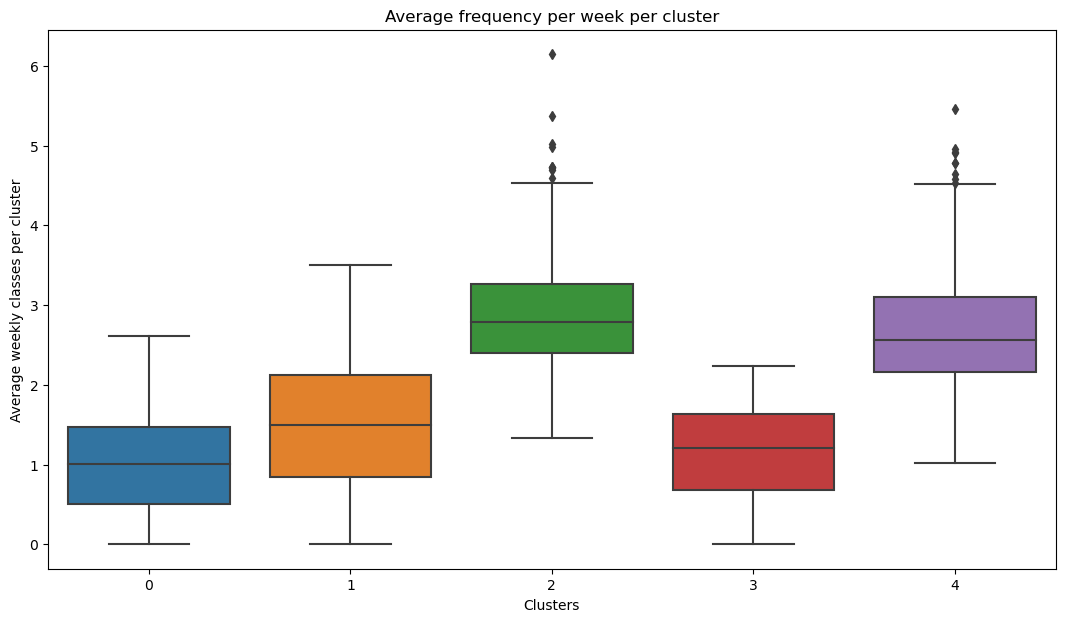

In [674]:
plt.figure(figsize=(13,7))
sns.boxplot(data=df, x='cluster', y='avg_class_frequency_current_month')
plt.title('Average frequency per week per cluster')
plt.xlabel('Clusters')
plt.ylabel('Average weekly classes per cluster')
plt.show()

The boxplot highlights clear differences in customer engagement levels between clusters. The **Cluster 2** has the highest average class attendance, indicating highly engaged clients and greater ongoing engagement with academia. The **Cluster 4** also shows good frequency of visits, although with greater variability.

In contrast, the **Clusters 0 and 3** display the lowest average frequencies, characterizing low-engagement profiles that are more susceptible to turnover. The **Cluster 1** occupies an intermediate position, with moderate frequency and potential for increased engagement through targeted actions.

These results reinforce that the frequency of participation is one of the main factors associated with customer retention and can be used as a key indicator for churn prevention strategies.

### 5.6 - Taxa de churn por cluster.

In [675]:
cluster_churn = df.groupby('cluster')['churn'].mean()
cluster_churn

cluster
0    0.587685
1    0.285940
2    0.013932
3    0.042279
4    0.105145
Name: churn, dtype: float64

The analysis of the churn rate per cluster shows significant differences in retention behavior between the identified groups.

The **Cluster 0** has the highest churn rate (  58.8%), characterizing customers with low engagement, short contracts and shorter relationship time. This group represents the highest risk of turnover and should be prioritized in early retention strategies.

 **Cluster 1** has an intermediate churn rate (  28.6%), indicating customers influenced by promotions and partnerships, which remain longer than Cluster 0, but still present considerable exit risk.

Clusters 2 and 3* have the lowest churn rates (  1.4% and 4.2%, respectively). These groups are composed of clients with long contracts, higher frequency of visits and greater stability, representing the most loyal profiles of the base.

The **Cluster 4** has a moderate churn rate (  10.5%), indicating relatively engaged customers, but with potential risk of turnover if they are not encouraged to maintain or expand their contractual bond.

These results reinforce that churn is strongly associated with engagement level and contract duration, allowing the definition of retention strategies targeted to each customer profile.

## 6 - Conclusions and recommendations.

### Conclusions

The analysis of data from the Model Fitness network showed that customer turnover is strongly related to the level of engagement, the duration of the contract and the time of relationship with the gym. Customers with low frequency of visits, short contracts and few months of bond have a higher probability of churn. On the other hand, clients with long contracts, high class attendance and higher consumption of additional services tend to stay longer and demonstrate greater loyalty.

The segmentation by clusters reinforced these findings, highlighting groups with high exit risk and others highly loyal, allowing a more targeted retention approach.

---

### Recommendations

Based on the results obtained, it is recommended:

1. **Act in the first months of the client**  
   Implement follow-up and engagement actions soon after joining, such as active contact, personalized training plans, and attendance incentives, reducing early churn.

2. **Encourage medium- and long-term contracts**  
   Offer financial benefits or bonuses to clients migrating from monthly plans to longer term contracts, reducing the turnover associated with short contracts.

3. **Encourage attendance and participation in group activities**  
   Promote collective classes, challenges and engagement programs, increasing customer interaction with academia and strengthening the bond.

4. **Retain high-value customers**  
   Create loyalty programs, exclusive benefits and personalized offers for more engaged and loyal customers, ensuring that groups are maintained with the lowest churn rate.

These actions enable a data-driven retention strategy, focusing on engagement, loyalty and reduction of turnover.